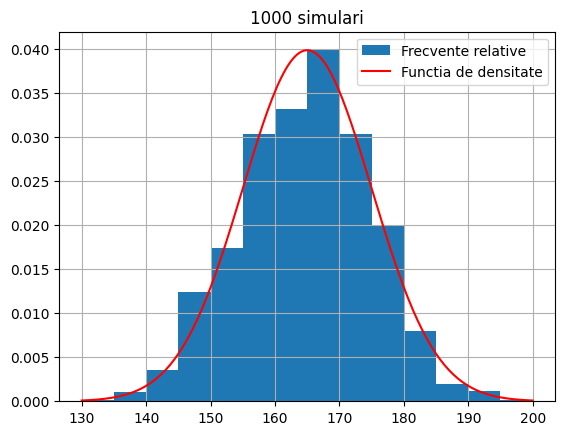

164.7190724999969 10.123907123859588
Proportie simulata 0.366
Proportie exacta 0.4172093435239395


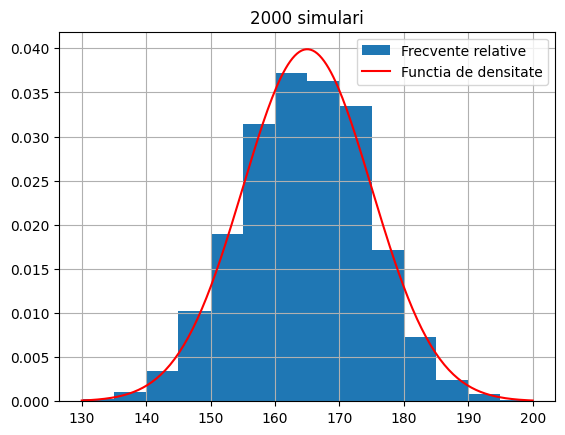

164.5386522996783 9.953078107384458
Proportie simulata 0.3675
Proportie exacta 0.4172093435239395


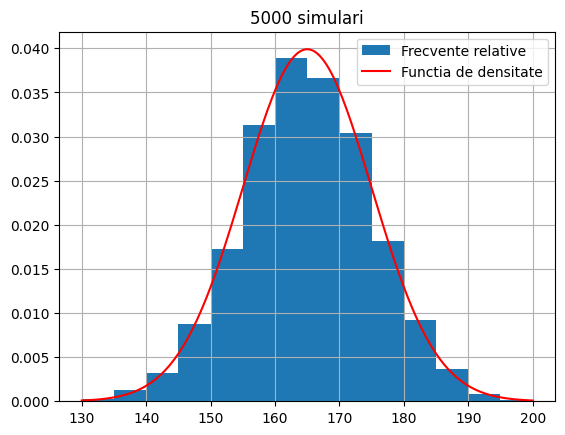

165.02089068962746 10.008099909204804
Proportie simulata 0.3774
Proportie exacta 0.4172093435239395


In [19]:
from scipy.stats import norm
from numpy import mean, std, linspace
from matplotlib.pyplot import hist, plot, grid, show, legend, title

def ab1():
    m = 165 #media
    sigma = 10 #std
    for n in [1000, 2000, 5000]:
        val = norm.rvs(loc=m, scale=sigma, size=n)
        hist(val, bins=14, range=(130,200), density=True, label="Frecvente relative")
        x = linspace(130,200,200)
        plot(x, norm.pdf(x, loc=m, scale=sigma), "r-", label="Functia de densitate")
        grid()
        title(str(n) + " simulari")
        legend()
        show()
        print(val.mean(), val.std())
        prop_sim = sum([160 <= x <= 170 for x in val])/n
        prop_ex = norm.cdf(170, loc=m, scale=sigma) - norm.cdf(159, loc=m, scale=sigma)
        print("Proportie simulata " + str(prop_sim))
        print("Proportie exacta " + str(prop_ex))

ab1()

In [123]:
from scipy.stats import uniform, expon

def abc2(nr_sim = 1):
    data=[]
    exp_param = 1/5
    for _ in range(nr_sim):
        x = uniform.rvs()
        if x <= 0.4:
            data.append(expon.rvs(scale=1/exp_param))
        else:
            data.append(uniform.rvs(4, 2))
    print(mean(data), std(data))
    print(sum([(x <= 5) for x in data])/len(data))
    print(0.4 * expon.cdf(5, scale=1/exp_param) + 0.6 * uniform.pdf(5, loc=4, scale=2))

abc2(10000)

4.9495795977998425 3.042675750943731
0.5526
0.552848223531423


In [151]:
from scipy.integrate import quad
from numpy import exp

def pb3():
    n = 5000
    a, b = -1, 3
    val = uniform.rvs(loc=a, scale=b-a, size=n)
    g = lambda x : exp(-x**2)
    print("Valoare estimata " + str((b-a)*mean(g(val))))
    print("Valoarea exacta " + str(quad(g, -1, 3)[0]))

pb3()

Valoare estimata 1.6345816754669682
Valoarea exacta 1.6330314810719482
